# VP-SDE DDPM++ on CIFAR-10 Birds without Augmentation

Train and evaluate a VP-SDE score model with a DDPM++/NCSN++ backbone on plain CIFAR-10 bird images.


## Configuration


In [ ]:
RUN_TRAINING = True
RUN_EVALUATION_AFTER_TRAINING = True

LOAD_FROM_CHECKPOINT = False

SAVE_CHECKPOINTS = False

target_class_name = "bird"
batch_size=128

# Training
epochs=1760
learning_rate = 1e-4
weight_decay=1e-4
ema_decay=0.995

# VP-SDE beta schedule
bar_b_min = 0.1
bar_b_max = 20.0

# Sampling
sample_num_steps = 1000
sample_eps = 1e-3
sample_snr = 0.01
sample_corrector_steps = 0

# Evaluation
fid_num_generated = 1000
fid_gen_batch_size = 64
mem_num_generated = 64
mem_reference_images = 5000

# Paths
path = "/content/drive/MyDrive/DD2424/Project/working_nets"


## Imports


In [ ]:
import os
import sys
import math
import time
import copy
import subprocess
import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import Subset, DataLoader
from torchvision.utils import make_grid
from tqdm import tqdm


## Google Drive


In [ ]:
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

from google.colab import drive

drive.mount("/content/drive")
os.makedirs(path, exist_ok=True)
project_root = os.path.dirname(path) if os.path.basename(path) == "working_nets" else path
if project_root not in sys.path:
    sys.path.insert(0, project_root)
if path not in sys.path:
    sys.path.insert(0, path)

print("Project path:", path)
print("Files in project path:", os.listdir(path))


Using device: cuda
Mounted at /content/drive
Project path: /content/drive/MyDrive/DD2424/Project/working_nets
Files in project path: ['score_sde_pytorch', 'bird_ncsnpp_ve_ema_checkpoint_epoch_500.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_621.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1000.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1500.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1759.pth', 'bird_ncsnpp_ve_ema_checkpoint_epoch_1760.pth']


In [ ]:
from src.plotting import denormalize, imshow, show_batch_from_loader, show_images, plot_loss, save_tensor_images_as_grid
from src.configs import create_ddpmpp_vp_config
from src.sde import update_ema


## Load CIFAR-10 Bird Data


In [ ]:
# Plain transform: used for visualization, FID real images, memorization check,
# and NON-AUGMENTED training.
transform_plain = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))])

# Load full plain training set to find bird indices.
# Important: there is no RandomHorizontalFlip, RandomCrop, padding, etc.
trainset_plain_full = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_plain)

target_idx = trainset_plain_full.classes.index(target_class_name)

train_indices = [
    i for i, label in enumerate(trainset_plain_full.targets)
    if label == target_idx
]

# Plain bird training set
trainset_plain = Subset(trainset_plain_full, train_indices)


trainloader_plain = DataLoader(trainset_plain, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

trainloader_non_augmented = DataLoader(trainset_plain, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)

trainloader = trainloader_non_augmented

# Test set: plain transform, bird class only
testset_full = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_plain)

test_indices = [
    i for i, label in enumerate(testset_full.targets)
    if label == target_idx
]

testset = Subset(testset_full, test_indices)

testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print("Target class:", target_class_name)
print("Target class index:", target_idx)
print("Number of bird training images:", len(trainset_plain))
print("Number of bird test images:", len(testset))
print("Steps per epoch:", math.ceil(len(trainset_plain) / batch_size))


100%|██████████| 170M/170M [00:06<00:00, 25.6MB/s]


Target class: bird
Target class index: 2
Number of bird training images: 5000
Number of bird test images: 1000
Steps per epoch: 40


## Visualize Training Images


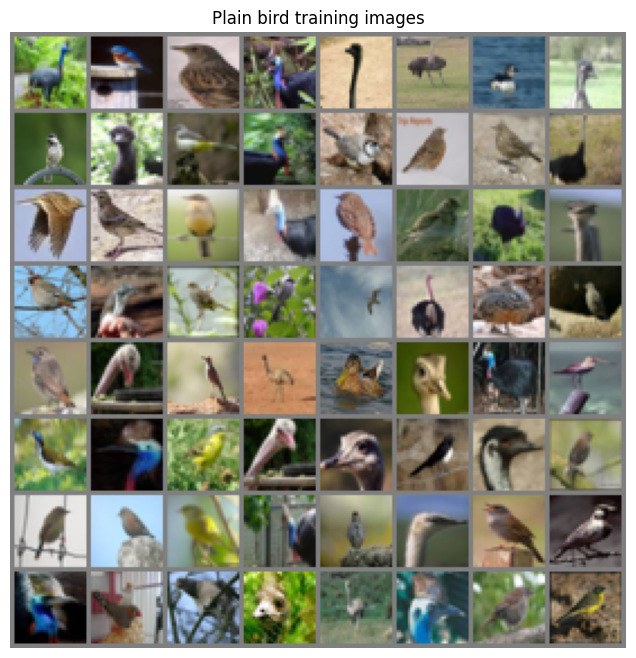

In [ ]:
show_batch_from_loader(trainloader_plain, title="Plain bird training images")


## Install DDPM++ Dependencies


In [ ]:
!pip install ninja #need this library to import from github


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 10.4 MB/s eta 0:00:00


## Load score_sde_pytorch


In [ ]:
from types import SimpleNamespace

score_sde_repository_path = os.path.join(path, "score_sde_pytorch")

if not os.path.exists(score_sde_repository_path):
    !git clone https://github.com/yang-song/score_sde_pytorch.git "{score_sde_repository_path}"

if score_sde_repository_path not in sys.path:
    sys.path.insert(0, score_sde_repository_path)

from models.ncsnpp import NCSNpp

print("imported NCSNpp architecture")


imported NCSNpp architecture


## Configure DDPM++ Model


## Score Model Wrapper


In [ ]:
class NCSNppVPScoreWrapper(nn.Module):
    def __init__(self, official_model, number_of_scales=1000):
        super().__init__()
        self.official_model = official_model
        self.number_of_scales = number_of_scales

        def forward(self, images, continuous_timesteps):
            timestep_labels = continuous_timesteps * (self.number_of_scales - 1)

            model_output = self.official_model(images, timestep_labels)

            _, standard_deviation = perturbation_kernel(continuous_timesteps, images)

            score = -model_output / standard_deviation

        return score

ncsnpp_config = create_ddpmpp_vp_config(image_size=32, image_channels=3)

official_ddpmpp_model = NCSNpp(ncsnpp_config).to(device)


## VP-SDE Objective


In [ ]:
def perturbation_kernel(t, x0):
    integral_beta = bar_b_min * t + 0.5 * (bar_b_max - bar_b_min) * t ** 2
    mean = torch.exp(-0.5 * integral_beta).view(-1, 1, 1, 1) * x0
    std = torch.sqrt(1.0 - torch.exp(-integral_beta)).view(-1, 1, 1, 1)
    return mean, std


def vp_loss(x0, net):
    """Continuous VP-SDE denoising score-matching loss."""
    B = x0.shape[0]
    eps=1e-5
    t = torch.rand(B, device=device) * (1.0 - eps) + eps
    z = torch.randn_like(x0)

    mean, std = perturbation_kernel(t, x0)
    x_t = mean + std * z

    score_target = -z / std
    score_pred = net(x_t, t)
    loss = (std ** 2 * ((score_pred - score_target) ** 2)).mean()
    return loss


def beta_t(t):
    return bar_b_min + t * (bar_b_max - bar_b_min)


## Initialize or Load Checkpoint


In [ ]:
if LOAD_FROM_CHECKPOINT:
    print("Loading checkpoint:", CHECKPOINT_TO_LOAD)

    checkpoint = torch.load(CHECKPOINT_TO_LOAD, map_location=device)


    #DDPMPP network
    vp_net = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in vp_net.parameters())

    #DDPMPP network
    ema_net = copy.deepcopy(vp_net).to(device)
    ema_net.eval()


    vp_net.load_state_dict(checkpoint["vp_net"])
    ema_net.load_state_dict(checkpoint["ema_net"])

    learning_rate = checkpoint.get("learning_rate", learning_rate)
    weight_decay=checkpoint.get("weight_decay", weight_decay)
    ema_decay=checkpoint.get("ema_decay", ema_decay)
    loss_hist = checkpoint.get("loss_hist", [])
    start_epoch=checkpoint.get("epochs", 0)

    print(start_epoch)

    optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

    optimizer.load_state_dict(checkpoint["optimizer"])

    for state in optimizer.state.values():
        for k, v in state.items():
            if torch.is_tensor(v):
                state[k] = v.to(device)

                vp_net.train()
                ema_net.eval()

            for p in ema_net.parameters():
                p.requires_grad_(False)

                print("Loaded checkpoint.")
                print("Start epoch:", start_epoch)
                print("Loaded loss history length:", len(loss_hist))

else:
    print("Initializing new model.")

    #DDPM network
    vp_net = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in vp_net.parameters())

    #DDPMPP network
    ema_net = copy.deepcopy(vp_net).to(device)
    ema_net.eval()


    for p in ema_net.parameters():
        p.requires_grad_(False)

        optimizer = optim.AdamW(vp_net.parameters(), lr=learning_rate, weight_decay=weight_decay)

        loss_hist = []
        start_epoch=0

        print("New model initialized.")


Initializing new model.
New model initialized.


## Training Loop


In [ ]:
def train_vp_sde(vp_net, ema_net, optimizer, trainloader, start_epoch=0, epochs=1760, ema_decay=0.995, checkpoint_every=500, checkpoint_prefix="bird_vp_sde_non_augmented_ddpmpp"):
    global loss_hist
    end_epoch = start_epoch + epochs

    for epoch in tqdm(range(start_epoch, end_epoch)):
        vp_net.train()
        ema_net.eval()
        epoch_losses = []

        for i, (images, _) in enumerate(trainloader):
            images = images.to(device)
            loss = vp_loss(images, vp_net)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vp_net.parameters(), max_norm=1.0)
            optimizer.step()
            update_ema(ema_net, vp_net, decay=ema_decay)

            loss_hist.append(loss.item())
            epoch_losses.append(loss.item())

        if epoch % 10 == 0:
            print(f"VP epoch {epoch} | Mean loss {np.mean(epoch_losses):.4f}")

        if SAVE_CHECKPOINTS and checkpoint_every is not None and (epoch + 1) % checkpoint_every == 0:
            checkpoint_path = os.path.join(path, f"{checkpoint_prefix}_{epoch + 1}_epochs.pth")
            checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
            checkpoint["epochs"] = epoch + 1
            checkpoint["batch_size"] = batch_size
            checkpoint["learning_rate"] = learning_rate
            checkpoint["weight_decay"] = weight_decay
            checkpoint["ema_decay"] = ema_decay
            checkpoint["bar_b_min"] = bar_b_min
            checkpoint["bar_b_max"] = bar_b_max
            checkpoint["augmentation"] = False
            checkpoint["target_class_name"] = target_class_name
            torch.save(checkpoint, checkpoint_path)
            print("Saved checkpoint:", checkpoint_path)

    return end_epoch


## Run Training


In [ ]:
if RUN_TRAINING:
    print("Training VP-SDE model...")
    final_epoch = train_vp_sde(vp_net, ema_net, optimizer, trainloader, start_epoch=start_epoch, epochs=epochs, ema_decay=ema_decay, checkpoint_every=500, checkpoint_prefix="bird_vp_sde_non_augmented_ddpmpp")
    final_checkpoint_path = os.path.join(path, f"bird_vp_sde_non_augmented_final_ddpmpp_{final_epoch}_epochs.pth")
    checkpoint = {"vp_net": vp_net.state_dict(), "ema_net": ema_net.state_dict(), "optimizer": optimizer.state_dict(), "loss_hist": loss_hist}
    checkpoint["epochs"] = final_epoch
    checkpoint["batch_size"] = batch_size
    checkpoint["learning_rate"] = learning_rate
    checkpoint["weight_decay"] = weight_decay
    checkpoint["ema_decay"] = ema_decay
    checkpoint["bar_b_min"] = bar_b_min
    checkpoint["bar_b_max"] = bar_b_max
    checkpoint["augmentation"] = False
    checkpoint["target_class_name"] = target_class_name
    torch.save(checkpoint, final_checkpoint_path)
    print("Saved final checkpoint:", final_checkpoint_path)

else:
    final_epoch = start_epoch


Training VP-SDE model...


  0%|          | 1/1760 [00:04<2:03:54,  4.23s/it]

VP epoch 0 | Mean loss 0.8151


  1%|          | 11/1760 [00:30<1:15:59,  2.61s/it]

VP epoch 10 | Mean loss 0.0385


...

VP epoch 1740 | Mean loss 0.0246


 99%|█████████▉| 1751/1760 [1:15:50<00:23,  2.59s/it]

VP epoch 1750 | Mean loss 0.0229


100%|██████████| 1760/1760 [1:16:13<00:00,  2.60s/it]

Saved final checkpoint: /content/drive/MyDrive/DD2424/Project/working_nets/bird_vp_sde_non_augmented_final_ddpmpp_1760_epochs.pth


## Plot Training Loss


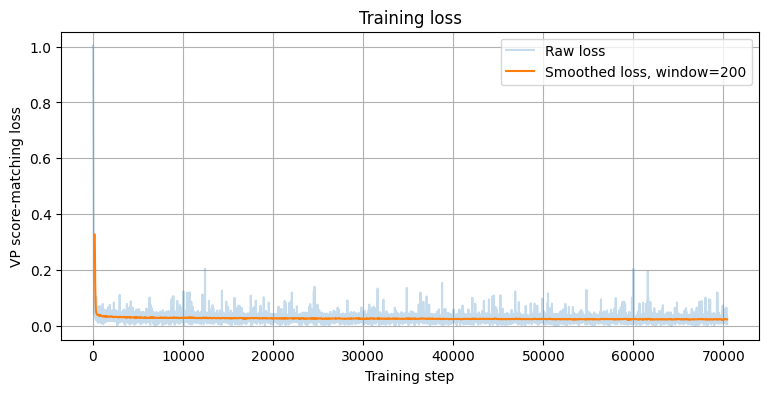

In [ ]:
plot_loss(loss_hist, smooth_window=200)


## Sampling


In [ ]:
@torch.no_grad()
def langevin_corrector_vp(x, t, net, snr=0.05, n_steps=1, eps=1e-12):
    B = x.shape[0]
    batch_t = torch.ones(B, device=device) * t

    for _ in range(n_steps):
        score = net(x, batch_t)
        noise = torch.randn_like(x)
        score_norm = torch.norm(score.reshape(B, -1), dim=1).mean()
        noise_norm = torch.norm(noise.reshape(B, -1), dim=1).mean()
        step_size = 2.0 * (snr * noise_norm / (score_norm + eps)) ** 2

        x_mean = x + step_size * score
        x = x_mean + torch.sqrt(2.0 * step_size) * noise

    return x, x_mean


@torch.no_grad()
def euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=True):
    B = x.shape[0]
    h = t - t_next
    batch_t = torch.ones(B, device=device) * t

    beta = beta_t(batch_t).view(-1, 1, 1, 1)
    score = net(x, batch_t)
    drift = 0.5 * beta * x + beta * score
    x_mean = x + drift * h

    if add_noise:
        noise = torch.randn_like(x)
        x = x_mean + torch.sqrt(beta * h) * noise
    else:
        x = x_mean

    return x, x_mean


@torch.no_grad()
def sample_pc_vp_sde_continuous(net, num_samples=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.05, corrector_steps=0, denoise=True):
    net.eval()
    x = torch.randn(num_samples, *img_shape, device=device)
    timesteps = torch.linspace(1.0, eps, num_steps, device=device)
    x_mean = x

    for i in tqdm(range(num_steps - 1)):
        t = timesteps[i]
        t_next = timesteps[i + 1]

        if corrector_steps > 0:
            x, x_mean = langevin_corrector_vp(x, t, net, snr=snr, n_steps=corrector_steps)

        add_noise = i < num_steps - 2
        x, x_mean = euler_maruyama_predictor_vp(x, t, t_next, net, add_noise=add_noise)

    return (x_mean if denoise else x).clamp(-1, 1)


## Compare Raw and EMA Samples


100%|██████████| 999/999 [00:07<00:00, 128.55it/s]


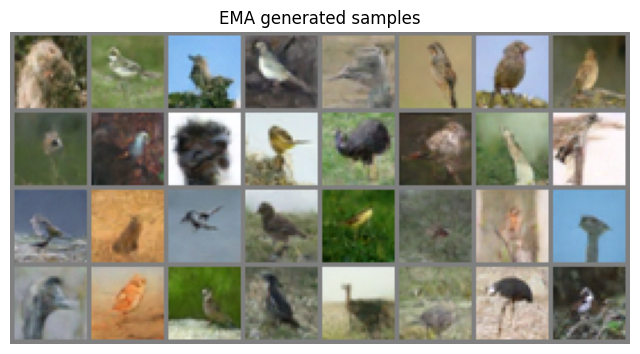

100%|██████████| 999/999 [00:07<00:00, 128.81it/s]


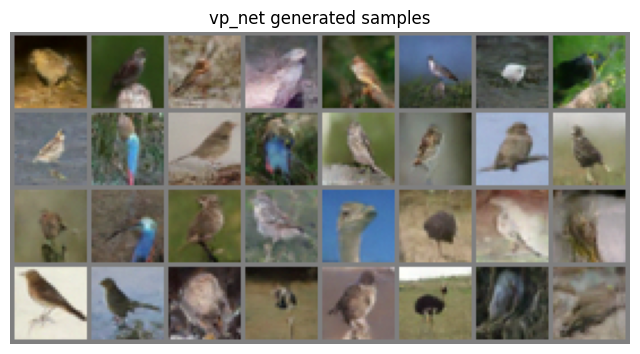

In [ ]:
samples_ema = sample_pc_vp_sde_continuous(ema_net, num_samples=32, img_shape=(3, 32, 32), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_ema, title="EMA generated samples", nrow=8)

samples_raw = sample_pc_vp_sde_continuous(vp_net, num_samples=32, img_shape=(3, 32, 32), num_steps=sample_num_steps,
    eps=sample_eps, snr=sample_snr, corrector_steps=sample_corrector_steps, denoise=True)

show_images(samples_raw, title="vp_net generated samples", nrow=8)


## Save Sample Grids


In [ ]:
save_tensor_images_as_grid(samples_ema, os.path.join(path, 'non_augmented_ema_generated_samples_grid.png'), nrow=8)

save_tensor_images_as_grid(samples_raw, os.path.join(path, 'non_augmented_vp_generated_samples_grid.png'), nrow=8)


Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/non_augmented_ema_generated_samples_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/non_augmented_vp_generated_samples_grid.png


## Batched Sampling


In [ ]:
@torch.no_grad()
def generate_samples_in_batches(model, total_samples=1000, sample_batch_size=64, img_shape=(3, 32, 32), num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True):
    model.eval()
    all_samples = []
    generated = 0

    while generated < total_samples:
        current_batch = min(sample_batch_size, total_samples - generated)
        samples = sample_pc_vp_sde_continuous(model, num_samples=current_batch, img_shape=img_shape, num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise)
        all_samples.append(samples.detach().cpu())
        generated += current_batch
        print(f"Generated {generated}/{total_samples} samples")

    return torch.cat(all_samples, dim=0)


## FID Evaluation


In [ ]:
def to_uint8_images(x):
    x = denormalize(x)
    x = (x * 255.0).round().clamp(0, 255).to(torch.uint8)
    return x


def install_fid_dependencies_if_needed():
    try:
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance
    except Exception:
        print("Installing torchmetrics and torch-fidelity...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "torchmetrics", "torch-fidelity"])
        from torchmetrics.image.fid import FrechetInceptionDistance
        return FrechetInceptionDistance


@torch.no_grad()
def compute_fid_for_model(model, real_loader, num_generated=1000, gen_batch_size=64, real_max_images=1000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, feature=2048):
    FrechetInceptionDistance = install_fid_dependencies_if_needed()
    fid = FrechetInceptionDistance(feature=feature, normalize=False).to(device)
    model.eval()

    real_count = 0
    for real_images, _ in real_loader:
        real_images = real_images.to(device)
        fid.update(to_uint8_images(real_images), real=True)
        real_count += real_images.shape[0]
        if real_count >= real_max_images:
            break

    print("Real images added to FID:", real_count)

    gen_count = 0
    while gen_count < num_generated:
        current_batch = min(gen_batch_size, num_generated - gen_count)
        samples = sample_pc_vp_sde_continuous(
            model, num_samples=current_batch, img_shape=(3, 32, 32),
            num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise
        )
        fid.update(to_uint8_images(samples), real=False)
        gen_count += current_batch
        print(f"Generated images added to FID: {gen_count}/{num_generated}")

    fid_value = fid.compute().item()
    print("FID:", fid_value)
    return fid_value


## Sampling-Step FID Experiment


In [ ]:
"""
def fid_sampling_steps_experiment(model, real_loader, steps_list=(100, 250, 500, 1000), num_generated=1000, gen_batch_size=64, corrector_steps=0):
    results = {}

    for steps in steps_list:
        print("\n====================================")
        print("Computing FID with num_steps=", steps)
        print("====================================")

        start_time = time.time()

        fid_value = compute_fid_for_model(model=model, real_loader=real_loader, num_generated=num_generated,
            gen_batch_size=gen_batch_size, real_max_images=1000, num_steps=steps, eps=1e-3, snr=0.01,
            corrector_steps=corrector_steps, denoise=True)

        elapsed = time.time() - start_time

        results[steps] = {
        "fid": fid_value,
        "time_seconds": elapsed
        }

        print(f"num_steps={steps} | FID={fid_value:.4f} | time={elapsed:.2f}s")

    return results"""


'\ndef fid_sampling_steps_experiment(\n    model,\n    real_loader,\n    steps_list=(100, 250, 500, 1000),\n    num_generated=1000,\n    gen_batch_size=64,\n    corrector_steps=0\n):\n    results = {}\n\n    for steps in steps_list:\n        print("\n====================================")\n        print("Computing FID with num_steps =", steps)\n        print("====================================")\n\n        start_time = time.time()\n\n        fid_value = compute_fid_for_model(\n            model=model,\n            real_loader=real_loader,\n            num_generated=num_generated,\n            gen_batch_size=gen_batch_size,\n            real_max_images=1000,\n            num_steps=steps,\n            eps=1e-3,\n            snr=0.01,\n            corrector_steps=corrector_steps,\n            denoise=True\n        )\n\n        elapsed = time.time() - start_time\n\n        results[steps] = {\n            "fid": fid_value,\n            "time_seconds": elapsed\n        }\n\n        print(f

## Memorization Helpers


In [ ]:
@torch.no_grad()
def collect_images_from_loader(loader, max_images=5000):
    all_images = []
    count = 0

    for images, _ in loader:
        images = images.to(device)
        all_images.append(images)
        count += images.shape[0]
        if count >= max_images:
            break

    all_images = torch.cat(all_images, dim=0)
    return all_images[:max_images]


@torch.no_grad()
def nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512):
    generated_images = generated_images.to(device)
    reference_images = reference_images.to(device)
    N = generated_images.shape[0]
    M = reference_images.shape[0]
    gen_flat = generated_images.reshape(N, -1)
    best_distances = torch.full((N,), float("inf"), device=device)
    best_indices = torch.zeros((N,), dtype=torch.long, device=device)

    for start in range(0, M, ref_batch_size):
        end = min(start + ref_batch_size, M)
        ref_batch = reference_images[start:end]
        ref_flat = ref_batch.reshape(ref_batch.shape[0], -1)
        dists = torch.cdist(gen_flat, ref_flat, p=2) ** 2 / gen_flat.shape[1]
        min_dists, min_idx = dists.min(dim=1)
        better = min_dists < best_distances
        best_distances[better] = min_dists[better]
        best_indices[better] = start + min_idx[better]

    return best_indices.detach().cpu(), best_distances.detach().cpu()


## Memorization Check

This code performs a memorization check for the generative model. The goal is to see whether the generated images are very close to images from the training set.

First, `collect_images_from_loader` collects a fixed number of real training images from the dataloader and stores them in one tensor. These images are used as the reference set.

Then, `nearest_neighbor_indices_pixel_mse` compares each generated image with all reference training images using pixel-wise mean squared error. Each image is flattened into a vector, and the distance is computed as

$$
d(g_i, x_j) = \frac{1}{D}\|g_i - x_j\|_2^2
$$

where $g_i$ is a generated image, $x_j$ is a training image, and $D$ is the total number of pixels and channels. For each generated image, the function finds the nearest training image:

$$
j^* = \arg\min_j d(g_i, x_j)
$$

The function `show_generated_vs_nearest` displays each generated image next to its closest training image, making it easier to visually inspect whether the model is copying training examples.

The main function, `memorization_check`, combines these steps. It collects reference training images, generates new samples, finds the nearest training image for each generated sample, prints summary statistics such as mean, median, minimum, and maximum nearest-neighbor MSE, and then shows visual comparisons.

Finally, `plot_nearest_neighbor_distance_histogram` plots the distribution of nearest-neighbor distances, while `save_memorization_report` saves the numerical results to a text file.

Overall, very small nearest-neighbor MSE values, especially together with visually similar image pairs, may indicate memorization. However, pixel-space MSE is only a rough diagnostic, so visual inspection is also important.


In [ ]:
def show_generated_vs_nearest(generated_images, reference_images, nearest_indices, nearest_distances=None, num_show=8):
    generated_images = generated_images.detach().cpu()
    reference_images = reference_images.detach().cpu()
    num_show = min(num_show, generated_images.shape[0])

    pairs = []
    for i in range(num_show):
        pairs.append(generated_images[i])
        pairs.append(reference_images[nearest_indices[i]])

    grid = make_grid(torch.stack(pairs, dim=0), nrow=2)
    img = denormalize(grid).numpy()
    plt.figure(figsize=(6, 3 * num_show))
    plt.imshow(np.transpose(img, (1, 2, 0)))
    plt.axis("off")

    if nearest_distances is not None:
        mean_dist = nearest_distances[:num_show].mean().item()
        plt.title(f"Generated vs nearest training image | mean MSE={mean_dist:.6f}")
    else:
        plt.title("Generated vs nearest training image")

    plt.show()


@torch.no_grad()
def memorization_check(model, trainloader_reference, num_generated=64, generation_batch_size=64, max_reference_images=5000, num_steps=1000, eps=1e-3, snr=0.01, corrector_steps=0, denoise=True, show_num=8):
    print("Collecting reference training images...")
    reference_images = collect_images_from_loader(trainloader_reference, max_images=max_reference_images)
    print("Reference images:", reference_images.shape)

    print("Generating images for memorization check...")
    generated_images = generate_samples_in_batches(model, total_samples=num_generated, sample_batch_size=generation_batch_size,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=eps, snr=snr, corrector_steps=corrector_steps, denoise=denoise).to(device)
    print("Generated images:", generated_images.shape)

    print("Finding nearest training neighbors...")
    nearest_indices, nearest_distances = nearest_neighbor_indices_pixel_mse(generated_images, reference_images, ref_batch_size=512)
    print("Mean nearest-neighbor MSE:", nearest_distances.mean().item())
    print("Median nearest-neighbor MSE:", nearest_distances.median().item())
    print("Minimum nearest-neighbor MSE:", nearest_distances.min().item())
    print("Maximum nearest-neighbor MSE:", nearest_distances.max().item())

    show_generated_vs_nearest(generated_images.cpu(), reference_images.cpu(), nearest_indices, nearest_distances, num_show=show_num)
    return {
        "generated_images": generated_images.detach().cpu(), "reference_images": reference_images.detach().cpu(),
        "nearest_indices": nearest_indices, "nearest_distances": nearest_distances
    }


def plot_nearest_neighbor_distance_histogram(mem_results, bins=30):
    distances = mem_results["nearest_distances"].numpy()
    plt.figure(figsize=(7, 4))
    plt.hist(distances, bins=bins)
    plt.xlabel("Nearest-neighbor pixel MSE")
    plt.ylabel("Number of generated samples")
    plt.title("Memorization check: nearest-neighbor distance distribution")
    plt.grid(True)
    plt.show()


def save_memorization_report(mem_results, filename):
    os.makedirs(os.path.dirname(filename), exist_ok=True)
    distances = mem_results["nearest_distances"].numpy()

    with open(filename, "w") as f:
        f.write("Memorization nearest-neighbor report\n")
        f.write("====================================\n")
        f.write(f"Number of generated samples: {len(distances)}\n")
        f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")
        f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")
        f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")
        f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")

    print("Saved memorization report:", filename)


JUnk


In [ ]:
# def save_memorization_report(mem_results, filename):
# os.makedirs(os.path.dirname(filename), exist_ok=True)
#
# distances = mem_results["nearest_distances"].numpy()
#
# with open(filename, "w") as f:
# f.write("Memorization nearest-neighbor report\n")
# f.write("====================================\n")
# f.write(f"Number of generated samples: {len(distances)}\n")
# f.write(f"Mean nearest-neighbor MSE: {distances.mean():.8f}\n")
# f.write(f"Median nearest-neighbor MSE: {np.median(distances):.8f}\n")
# f.write(f"Minimum nearest-neighbor MSE: {distances.min():.8f}\n")
# f.write(f"Maximum nearest-neighbor MSE: {distances.max():.8f}\n")
# f.write("\n")
# f.write("Interpretation:\n")
# f.write(
# "Very small nearest-neighbor distances may indicate memorization, "
# "especially if generated images visually match training images. "
# "Larger distances suggest that generated images are not simple copies, "
# "although pixel-space MSE is only a rough diagnostic.\n"
# )
#
# print("Saved memorization report:", filename)


## Compare Raw and EMA Models


In [ ]:
def compare_raw_vs_ema(vp_net, ema_net, num_samples=64, num_steps=1000, corrector_steps=0):
    torch.manual_seed(0)
    samples_raw = generate_samples_in_batches(
        model=vp_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    torch.manual_seed(0)
    samples_ema = generate_samples_in_batches(
        model=ema_net, total_samples=num_samples, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    show_images(samples_raw[:64], title="Raw vp_net samples", nrow=8)
    show_images(samples_ema[:64], title="EMA ema_net samples", nrow=8)
    save_tensor_images_as_grid(samples_raw[:64], os.path.join(path, 'non_augmented_comparison_raw_vp_net_grid.png'), nrow=8)
    save_tensor_images_as_grid(samples_ema[:64], os.path.join(path, 'non_augmented_comparison_ema_net_grid.png'), nrow=8)
    return samples_raw, samples_ema


## Full Evaluation


In [ ]:
def run_full_evaluation(model, model_name="ema_net", fid_num_generated=1000, mem_num_generated=64, num_steps=1000, corrector_steps=0):
    print("\n====================================")
    print("Running full evaluation for:", model_name)
    print("====================================")

    samples = generate_samples_in_batches(
        model=model, total_samples=64, sample_batch_size=64,
        img_shape=(3, 32, 32), num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )
    show_images(samples[:64], title=f"{model_name}: generated samples", nrow=8)
    save_tensor_images_as_grid(samples[:64], os.path.join(path, f'{model_name}_generated_grid.png'), nrow=8)

    fid_value = compute_fid_for_model(
        model, testloader, num_generated=fid_num_generated, gen_batch_size=fid_gen_batch_size,
        real_max_images=1000, num_steps=num_steps, eps=1e-3, snr=0.01, corrector_steps=corrector_steps, denoise=True
    )

    mem_results = memorization_check(model, trainloader_plain, num_generated=mem_num_generated, generation_batch_size=64,
        max_reference_images=mem_reference_images, num_steps=num_steps, eps=1e-3, snr=0.01,
        corrector_steps=corrector_steps, denoise=True, show_num=8)
    plot_nearest_neighbor_distance_histogram(mem_results)

    results = {"model_name": model_name, "fid": fid_value, "num_steps": num_steps, "corrector_steps": corrector_steps}
    results["mem_mean_nn_mse"] = mem_results["nearest_distances"].mean().item()
    results["mem_median_nn_mse"] = mem_results["nearest_distances"].median().item()
    results["mem_min_nn_mse"] = mem_results["nearest_distances"].min().item()
    results["mem_max_nn_mse"] = mem_results["nearest_distances"].max().item()

    results_path = os.path.join(path, f"{model_name}_evaluation_results.txt")
    with open(results_path, "w") as f:
        for k, v in results.items():
            f.write(f"{k}: {v}\n")

    print("Saved evaluation results:", results_path)
    print(results)
    return results


## Evaluate After Training


100%|██████████| 999/999 [00:07<00:00, 131.66it/s]


Generated 24/24 samples


100%|██████████| 999/999 [00:07<00:00, 132.17it/s]


Generated 24/24 samples


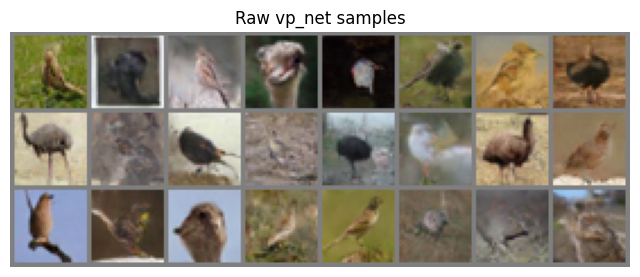

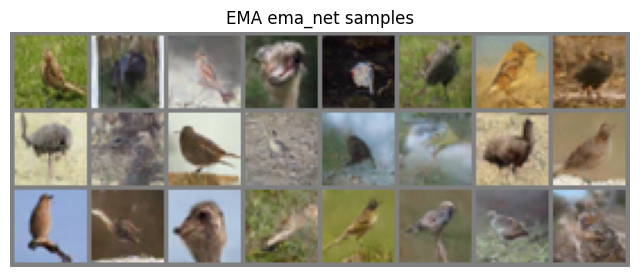

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/non_augmented_comparison_raw_vp_net_grid.png
Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/non_augmented_comparison_ema_net_grid.png

Running full evaluation for: raw_vp_net_bird_non_augmented_1760_epochs


100%|██████████| 999/999 [00:11<00:00, 90.16it/s]


Generated 64/64 samples


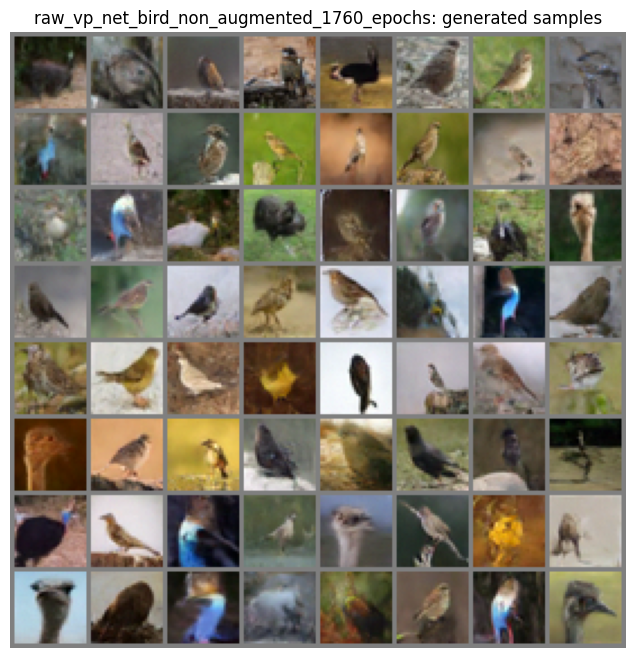

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_bird_non_augmented_1760_epochs_generated_grid.png
Installing torchmetrics and torch-fidelity...


Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:00<00:00, 184MB/s]


Real images added to FID: 1000


100%|██████████| 999/999 [00:10<00:00, 91.23it/s]


Generated images added to FID: 64/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:08<00:00, 121.59it/s]


Generated images added to FID: 1000/1000
FID: 63.020381927490234
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [00:10<00:00, 90.92it/s]


Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.0688709169626236
Median nearest-neighbor MSE: 0.06229328736662865
Minimum nearest-neighbor MSE: 0.029339073225855827
Maximum nearest-neighbor MSE: 0.17705272138118744


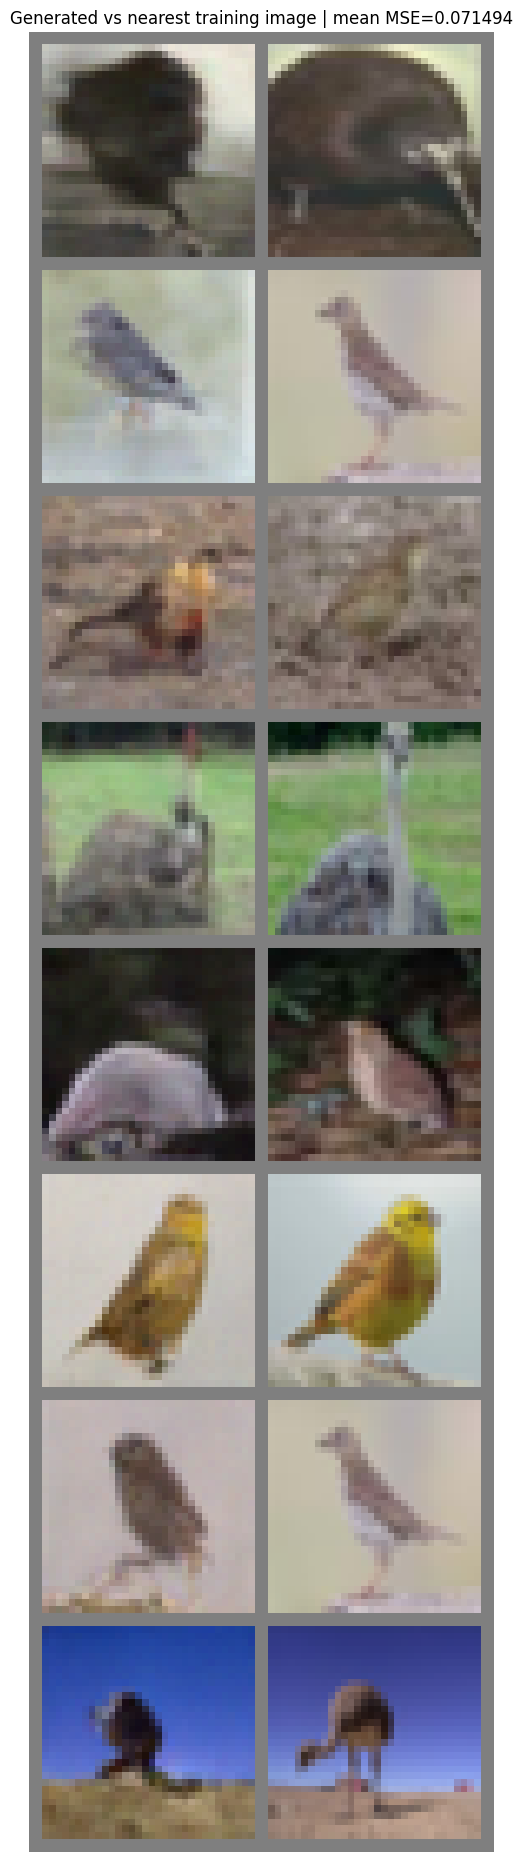

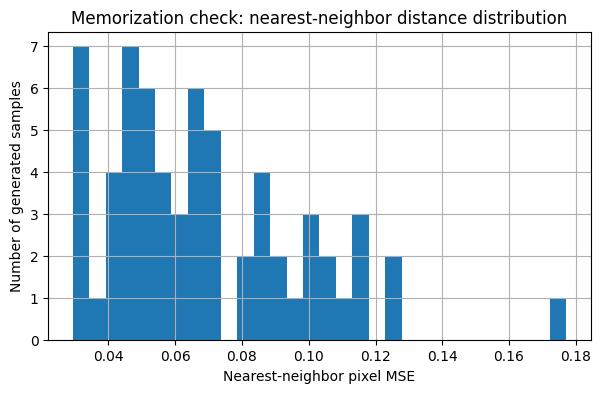

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/raw_vp_net_bird_non_augmented_1760_epochs_evaluation_results.txt
{'model_name': 'raw_vp_net_bird_non_augmented_1760_epochs', 'fid': 63.020381927490234, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.0688709169626236, 'mem_median_nn_mse': 0.06229328736662865, 'mem_min_nn_mse': 0.029339073225855827, 'mem_max_nn_mse': 0.17705272138118744}
Final raw VP-net evaluation results:
{'model_name': 'raw_vp_net_bird_non_augmented_1760_epochs', 'fid': 63.020381927490234, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.0688709169626236, 'mem_median_nn_mse': 0.06229328736662865, 'mem_min_nn_mse': 0.029339073225855827, 'mem_max_nn_mse': 0.17705272138118744}

Running full evaluation for: ema_vp_net_bird_non_augmented_1760_epochs


100%|██████████| 999/999 [00:10<00:00, 90.88it/s]


Generated 64/64 samples


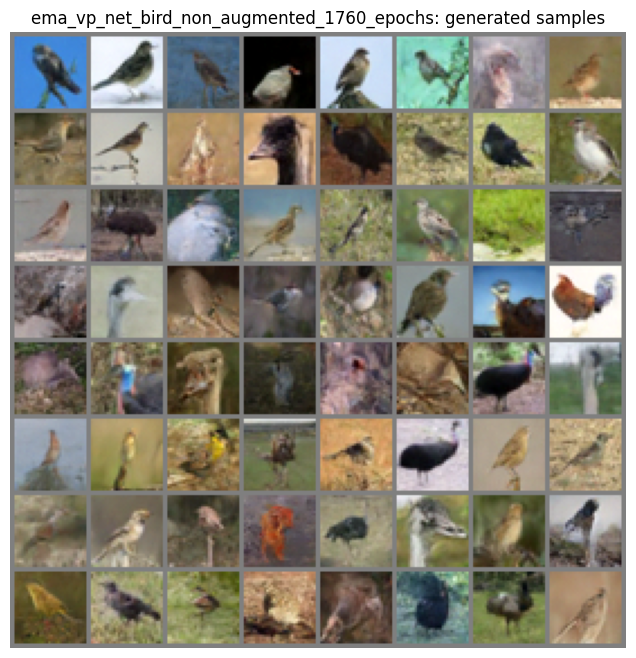

Saved image grid: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_bird_non_augmented_1760_epochs_generated_grid.png
Real images added to FID: 1000


100%|██████████| 999/999 [00:10<00:00, 91.05it/s]


Generated images added to FID: 64/1000


100%|██████████| 999/999 [00:10<00:00, 91.02it/s]


Generated images added to FID: 128/1000


...

Generated images added to FID: 960/1000


100%|██████████| 999/999 [00:08<00:00, 122.35it/s]


Generated images added to FID: 1000/1000
FID: 60.147544860839844
Reference images: torch.Size([5000, 3, 32, 32])
Generating images for memorization check...


100%|██████████| 999/999 [00:10<00:00, 91.43it/s]

Generated 64/64 samples
Generated images: torch.Size([64, 3, 32, 32])
Finding nearest training neighbors...
Mean nearest-neighbor MSE: 0.06358521431684494
Median nearest-neighbor MSE: 0.06059074401855469
Minimum nearest-neighbor MSE: 0.02403949946165085
Maximum nearest-neighbor MSE: 0.1322578489780426


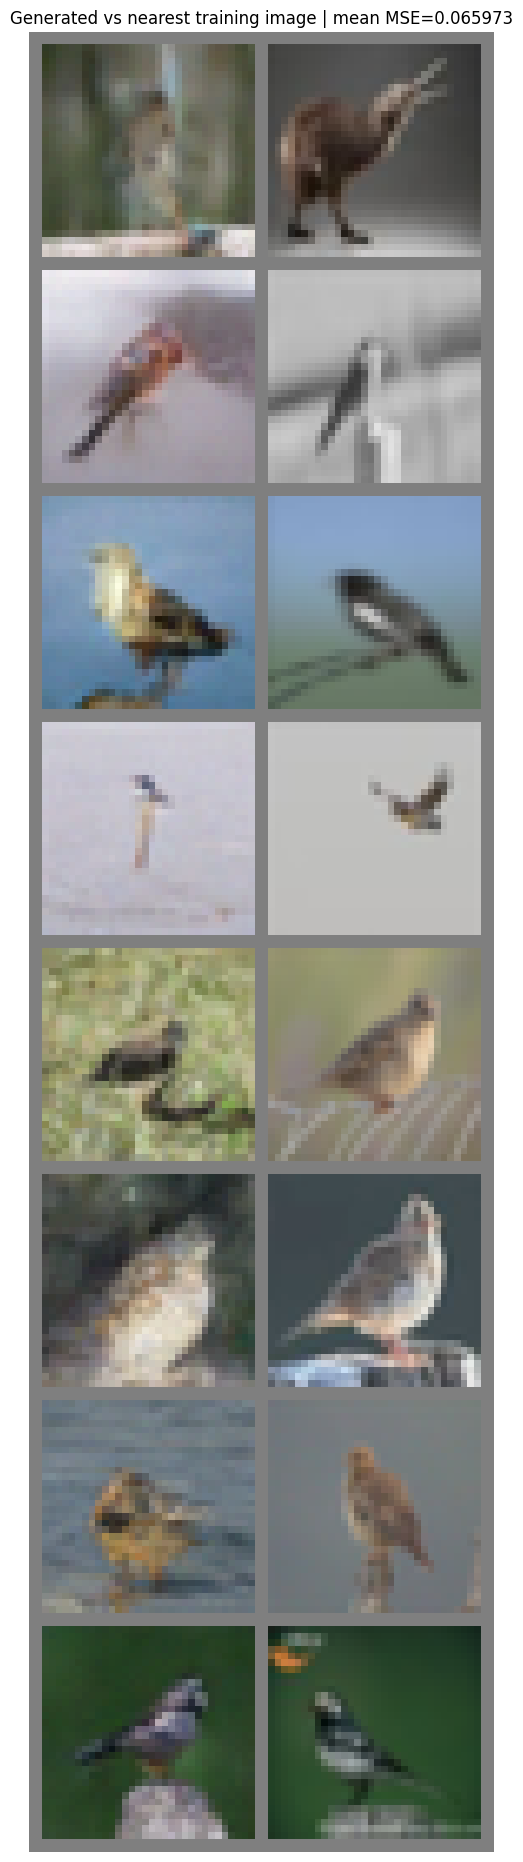

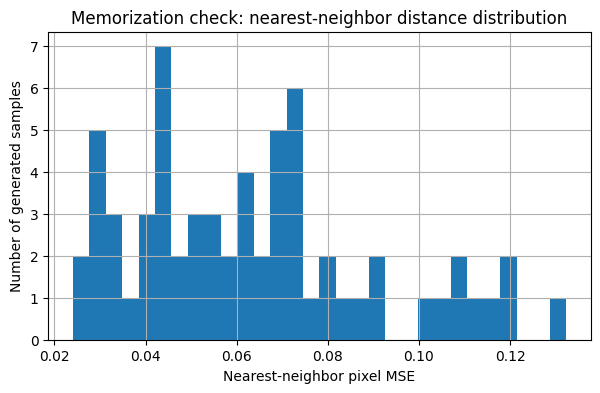

Saved evaluation results: /content/drive/MyDrive/DD2424/Project/working_nets/ema_vp_net_bird_non_augmented_1760_epochs_evaluation_results.txt
{'model_name': 'ema_vp_net_bird_non_augmented_1760_epochs', 'fid': 60.147544860839844, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.06358521431684494, 'mem_median_nn_mse': 0.06059074401855469, 'mem_min_nn_mse': 0.02403949946165085, 'mem_max_nn_mse': 0.1322578489780426}
Final EMA VP-net evaluation results:
{'model_name': 'ema_vp_net_bird_non_augmented_1760_epochs', 'fid': 60.147544860839844, 'num_steps': 1000, 'corrector_steps': 0, 'mem_mean_nn_mse': 0.06358521431684494, 'mem_median_nn_mse': 0.06059074401855469, 'mem_min_nn_mse': 0.02403949946165085, 'mem_max_nn_mse': 0.1322578489780426}


In [ ]:
if RUN_EVALUATION_AFTER_TRAINING:
    # Compare raw and EMA models visually
    samples_raw_compare, samples_ema_compare = compare_raw_vs_ema(vp_net=vp_net, ema_net=ema_net, num_samples=24, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    # Full evaluation on the current raw VP model
    raw_vp_results = run_full_evaluation(model=vp_net,
        model_name=f"raw_vp_net_bird_non_augmented_{final_epoch}_epochs", fid_num_generated=fid_num_generated,
        mem_num_generated=mem_num_generated, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    print("Final raw VP-net evaluation results:")
    print(raw_vp_results)

    # Full evaluation on the current EMA VP model
    ema_vp_results = run_full_evaluation(model=ema_net,
        model_name=f"ema_vp_net_bird_non_augmented_{final_epoch}_epochs", fid_num_generated=fid_num_generated,
        mem_num_generated=mem_num_generated, num_steps=sample_num_steps, corrector_steps=sample_corrector_steps)

    print("Final EMA VP-net evaluation results:")
    print(ema_vp_results)


## Evaluate Saved Checkpoint


In [ ]:
# Optional: evaluate a saved checkpoint separately.
# Keep this False when training/evaluating the current run above, otherwise you will run evaluation twice.
RUN_STANDALONE_CHECKPOINT_EVALUATION = False

if RUN_STANDALONE_CHECKPOINT_EVALUATION:
    eval_epoch = 1760

    eval_checkpoint_path = os.path.join(path, f'bird_vp_sde_non_augmented_final_ddpmpp_{eval_epoch}_epochs.pth')

    # the same settings as before
    eval_num_steps = 1000
    eval_corrector_steps = 0

    # FID/memorization sample counts
    # Keep these fixed across augmented and non-augmented models for fair comparison.
    eval_fid_num_generated = 1000
    eval_mem_num_generated = 64

    assert os.path.exists(eval_checkpoint_path), f"Checkpoint not found: {eval_checkpoint_path}"

    print("Evaluation checkpoint:", eval_checkpoint_path)
    print("FID generated samples:", eval_fid_num_generated)
    print("Memorization generated samples:", eval_mem_num_generated)
    print("Sampling steps:", eval_num_steps)

    checkpoint = torch.load(eval_checkpoint_path, map_location=device)


    # #DDPMPP network
    vp_net_1760 = NCSNppVPScoreWrapper(official_model=official_ddpmpp_model, number_of_scales=ncsnpp_config.model.num_scales).to(device)

    number_of_parameters = sum(parameter.numel() for parameter in vp_net_1760.parameters())

    #DDPMPP network
    ema_net_1760 = copy.deepcopy(vp_net_1760).to(device)
    ema_net_1760.eval()

    vp_net_1760.load_state_dict(checkpoint["vp_net"])
    ema_net_1760.load_state_dict(checkpoint["ema_net"])

    vp_net_1760.eval()
    ema_net_1760.eval()

    for p in vp_net_1760.parameters():
        p.requires_grad_(False)

    for p in ema_net_1760.parameters():
        p.requires_grad_(False)

        # Restore VP-SDE beta schedule from checkpoint if it exists
        bar_b_min = checkpoint.get("bar_b_min", bar_b_min)
        bar_b_max = checkpoint.get("bar_b_max", bar_b_max)

        loaded_epoch = checkpoint.get("epochs", eval_epoch)
        loaded_target_class = checkpoint.get("target_class_name", target_class_name)
        loaded_augmentation = checkpoint.get("augmentation", "unknown")

        print("Loaded checkpoint successfully.")
        print("Loaded epoch:", loaded_epoch)
        print("Target class:", loaded_target_class)
        print("Augmentation:", loaded_augmentation)
        print("bar_b_min:", bar_b_min)
        print("bar_b_max:", bar_b_max)

        raw_vp_1760_results = run_full_evaluation(model=vp_net_1760, model_name=f"raw_vp_net_bird_{eval_epoch}_epochs",
            fid_num_generated=eval_fid_num_generated, mem_num_generated=eval_mem_num_generated,
            num_steps=eval_num_steps, corrector_steps=eval_corrector_steps)

        print("Raw VP-net evaluation results:")
        print(raw_vp_1760_results)

        ema_vp_1760_results = run_full_evaluation(model=ema_net_1760,
            model_name=f"ema_vp_net_bird_{eval_epoch}_epochs", fid_num_generated=eval_fid_num_generated,
            mem_num_generated=eval_mem_num_generated, num_steps=eval_num_steps, corrector_steps=eval_corrector_steps)

        print("EMA VP-net evaluation results:")
        print(ema_vp_1760_results)
